<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/Monte_Carlo_CPU_vs_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo Simulation: CPU vs GPU Performance

This notebook demonstrates how GPUs can dramatically speed up Monte Carlo simulations.

## Why GPUs?

Monte Carlo simulations are **embarrassingly parallel** — each random trial is independent. GPUs have thousands of cores designed to run the same operation on many data points simultaneously, making them ideal for this workload.

## Setup

**Important:** Before running this notebook, enable GPU in Colab:
1. Go to **Runtime → Change runtime type**
2. Set **Hardware accelerator** to **T4 GPU**
3. Click **Save**

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# CuPy is NumPy-compatible but runs on GPU (pre-installed in Colab)
import cupy as cp

# Verify GPU is available
print(f"GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
print(f"CuPy version: {cp.__version__}")
print(f"NumPy version: {np.__version__}")

GPU: Tesla T4
CuPy version: 14.0.1
NumPy version: 2.0.2


---
## Example 1: Estimating π with Random Points

A classic Monte Carlo example. We throw random darts at a unit square and count how many land inside the inscribed quarter-circle.

The ratio of points inside the circle to total points approximates π/4:

$$\pi \approx 4 \times \frac{\text{points inside circle}}{\text{total points}}$$

<img src="https://upload.wikimedia.org/wikipedia/commons/8/84/Pi_30K.gif" width="250">

In [ ]:
def estimate_pi_cpu(n):
    """Estimate π using n random points on CPU (NumPy)."""
    x = np.random.uniform(0, 1, n)
    y = np.random.uniform(0, 1, n)
    inside = np.sum(x**2 + y**2 <= 1.0)
    return 4.0 * inside / n

def estimate_pi_gpu(n):
    """Estimate π using n random points on GPU (CuPy)."""
    x = cp.random.uniform(0, 1, n)
    y = cp.random.uniform(0, 1, n)
    inside = cp.sum(x**2 + y**2 <= 1.0)
    return 4.0 * float(inside) / n

In [ ]:
# Warm up GPU (first call includes initialization overhead)
_ = estimate_pi_gpu(1000)
cp.cuda.Device(0).synchronize() #(stop CPU host, synchronize to ensure GPU work is complete)

# Compare across increasing sample sizes
sample_sizes = [100_000, 1_000_000, 10_000_000, 50_000_000, 100_000_000]

print(f"{'N':>15s} | {'CPU Time':>10s} | {'GPU Time':>10s} | {'Speedup':>8s} | {'π Estimate (GPU)'}")
print("-" * 78)

cpu_times_pi = []
gpu_times_pi = []

for n in sample_sizes:  # better to run multiple times to get average timing
    # CPU timing
    start = time.time()
    pi_cpu = estimate_pi_cpu(n)
    cpu_time = time.time() - start

    # GPU timing (stop CPU host, synchronize to ensure GPU work is complete)
    cp.cuda.Device(0).synchronize()
    start = time.time()
    pi_gpu = estimate_pi_gpu(n)
    cp.cuda.Device(0).synchronize()
    gpu_time = time.time() - start

    speedup = cpu_time / gpu_time if gpu_time > 0 else float('inf')
    cpu_times_pi.append(cpu_time)
    gpu_times_pi.append(gpu_time)

    print(f"{n:>15,d} | {cpu_time:>9.4f}s | {gpu_time:>9.4f}s | {speedup:>7.1f}x | {pi_gpu:.6f}")

print(f"\nTrue value of π: {np.pi:.6f}")

              N |   CPU Time |   GPU Time |  Speedup | π Estimate (GPU)
------------------------------------------------------------------------------
        100,000 |    0.0060s |    0.0008s |     7.3x | 3.141240
      1,000,000 |    0.0275s |    0.0059s |     4.6x | 3.142632
     10,000,000 |    0.2594s |    0.0588s |     4.4x | 3.141300
     50,000,000 |    1.3151s |    0.2583s |     5.1x | 3.141447
    100,000,000 |    2.7348s |    0.4164s |     6.6x | 3.141633

True value of π: 3.141593


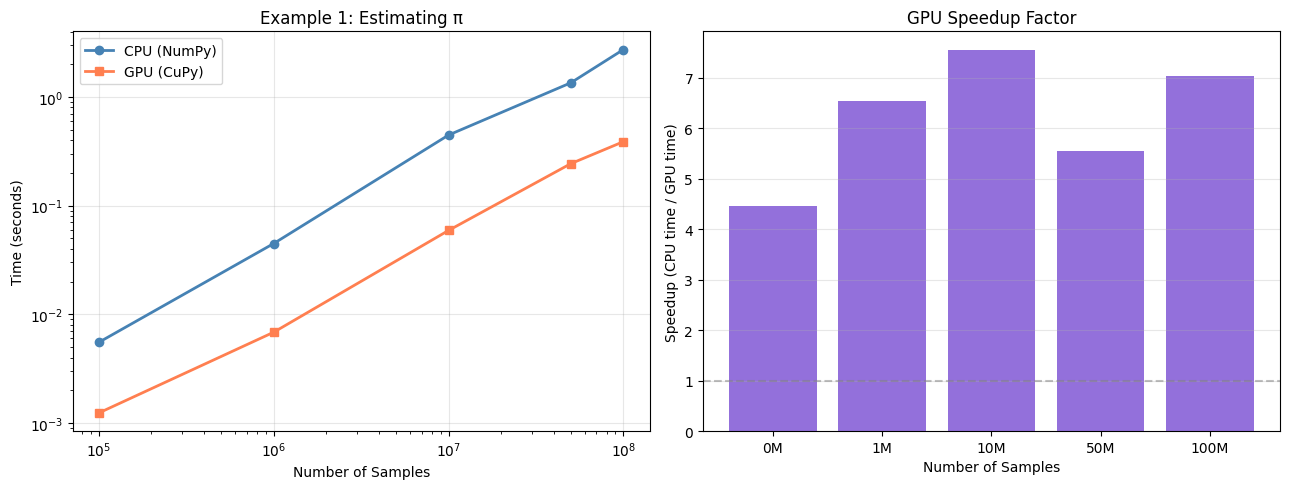

In [ ]:
# Visualize the speedup
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Runtime comparison
ax = axes[0]
ax.plot(sample_sizes, cpu_times_pi, 'o-', label='CPU (NumPy)', color='steelblue', linewidth=2)
ax.plot(sample_sizes, gpu_times_pi, 's-', label='GPU (CuPy)', color='coral', linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Time (seconds)')
ax.set_title('Example 1: Estimating π')
ax.legend()
ax.grid(True, alpha=0.3)

# Speedup
ax = axes[1]
speedups = [c / g for c, g in zip(cpu_times_pi, gpu_times_pi)]
ax.bar([f"{n/1e6:.0f}M" for n in sample_sizes], speedups, color='mediumpurple')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Speedup (CPU time / GPU time)')
ax.set_title('GPU Speedup Factor')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Example 2: Bootstrap Confidence Interval

Bootstrapping is a resampling technique central to modern statistics. We repeatedly sample **with replacement** from observed data to estimate the sampling distribution of a statistic (here, the polulation mean).

This is computationally intensive because we need thousands of resamples, each the same size as the original dataset.

In [ ]:
# Generate some "observed" data (e.g., patient recovery times)
np.random.seed(42)
data_np = np.random.exponential(scale=5.0, size=10_000)  # 10K observations
data_cp = cp.asarray(data_np) # resides in GPU memory

def bootstrap_ci_cpu(data, n_bootstrap, confidence=0.95):
    """Compute bootstrap CI for the mean on CPU."""
    n = len(data)
    means = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample = data[np.random.randint(0, n, size=n)]
        means[i] = np.mean(sample)
    alpha = (1 - confidence) / 2
    return np.percentile(means, [alpha * 100, (1 - alpha) * 100])

def bootstrap_ci_cpu_vectorized(data, n_bootstrap, confidence=0.95):
    """Vectorized bootstrap on CPU — generates all resamples at once."""
    n = len(data)
    indices = np.random.randint(0, n, size=(n_bootstrap, n))
    means = np.mean(data[indices], axis=1)
    alpha = (1 - confidence) / 2
    return np.percentile(means, [alpha * 100, (1 - alpha) * 100])

def bootstrap_ci_gpu(data, n_bootstrap, confidence=0.95):
    """Vectorized bootstrap on GPU."""
    n = len(data)
    indices = cp.random.randint(0, n, size=(n_bootstrap, n))
    means = cp.mean(data[indices], axis=1)
    alpha = (1 - confidence) / 2
    result = cp.percentile(means, [alpha * 100, (1 - alpha) * 100])
    return cp.asnumpy(result) # bring the results back to the CPU

In [ ]:
# Warm up
_ = bootstrap_ci_gpu(data_cp, 100)
cp.cuda.Device(0).synchronize()

bootstrap_sizes = [1_000, 5_000, 10_000, 50_000]

print(f"{'Resamples':>12s} | {'CPU (loop)':>11s} | {'CPU (vec)':>11s} | {'GPU':>10s} | {'GPU Speedup':>12s} | {'95% CI (GPU)'}")
print("-" * 95)

cpu_loop_times = []
cpu_vec_times = []
gpu_boot_times = []

for n_boot in bootstrap_sizes:
    # CPU with loop
    start = time.time()
    ci_loop = bootstrap_ci_cpu(data_np, n_boot)
    t_loop = time.time() - start

    # CPU vectorized
    start = time.time()
    ci_vec = bootstrap_ci_cpu_vectorized(data_np, n_boot)
    t_vec = time.time() - start

    # GPU
    cp.cuda.Device(0).synchronize()
    start = time.time()
    ci_gpu = bootstrap_ci_gpu(data_cp, n_boot)
    cp.cuda.Device(0).synchronize()
    t_gpu = time.time() - start

    cpu_loop_times.append(t_loop)
    cpu_vec_times.append(t_vec)
    gpu_boot_times.append(t_gpu)

    speedup_vs_vec = t_vec / t_gpu
    print(f"{n_boot:>12,d} | {t_loop:>10.4f}s | {t_vec:>10.4f}s | {t_gpu:>9.4f}s | {speedup_vs_vec:>10.1f}x | [{ci_gpu[0]:.4f}, {ci_gpu[1]:.4f}]")

    # The drop in GPU speedup at 50,000 resamples is likely due to the increasing overhead associated with managing and transferring extremely large datasets on the GPU.

   Resamples |  CPU (loop) |   CPU (vec) |        GPU |  GPU Speedup | 95% CI (GPU)
-----------------------------------------------------------------------------------------------
       1,000 |     0.1947s |     0.1879s |    0.0054s |       34.7x | [4.8003, 4.9818]
       5,000 |     0.8975s |     0.9788s |    0.0228s |       43.0x | [4.7927, 4.9863]
      10,000 |     2.4915s |     1.9763s |    0.0439s |       45.0x | [4.7925, 4.9833]
      50,000 |     9.1847s |    10.0135s |    0.4763s |       21.0x | [4.7918, 4.9835]


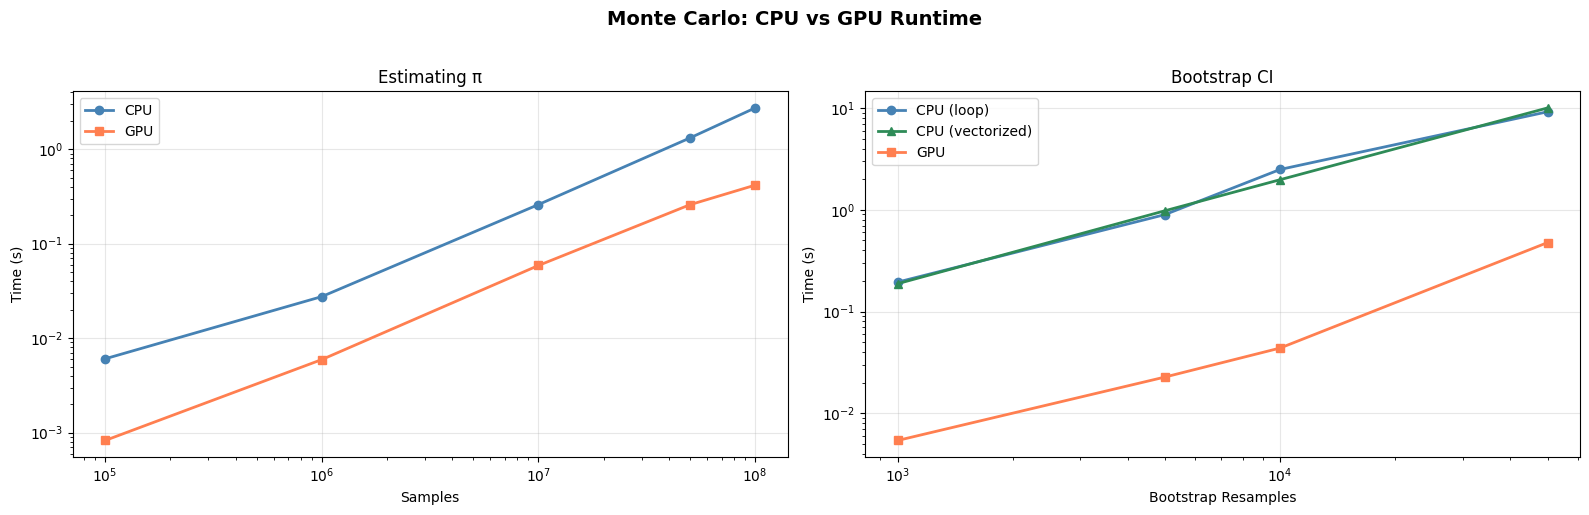

In [ ]:
# Combined visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Example 1: Pi
ax = axes[0]
ax.plot(sample_sizes, cpu_times_pi, 'o-', label='CPU', color='steelblue', linewidth=2)
ax.plot(sample_sizes, gpu_times_pi, 's-', label='GPU', color='coral', linewidth=2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Samples'); ax.set_ylabel('Time (s)')
ax.set_title('Estimating π'); ax.legend(); ax.grid(True, alpha=0.3)


# Example 2: Bootstrap
ax = axes[1]
ax.plot(bootstrap_sizes, cpu_loop_times, 'o-', label='CPU (loop)', color='steelblue', linewidth=2)
ax.plot(bootstrap_sizes, cpu_vec_times, '^-', label='CPU (vectorized)', color='seagreen', linewidth=2)
ax.plot(bootstrap_sizes, gpu_boot_times, 's-', label='GPU', color='coral', linewidth=2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Bootstrap Resamples'); ax.set_ylabel('Time (s)')
ax.set_title('Bootstrap CI'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Monte Carlo: CPU vs GPU Runtime', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Key Takeaways

| Aspect | CPU (NumPy) | GPU (CuPy) |
|--------|------------|------------|
| **Cores** | 2–8 (Colab) | ~2,500+ (T4) |
| **Best for** | Small data, complex logic | Massive parallel operations |
| **Overhead** | Minimal startup | GPU memory transfer cost |
| **Code changes** | — | Replace `np` with `cp` |

### When does GPU help?
- **Large N**: GPU overhead is fixed; benefits grow with problem size
- **Parallelizable work**: Each simulation is independent (no dependencies between trials)
- **Vectorizable operations**: Array math, not Python loops

### When does GPU NOT help?
- Small sample sizes (transfer overhead dominates)
- Sequential/iterative algorithms (e.g., MCMC chains with dependencies)
- Complex branching logic that doesn't vectorize well

### Practical tip
Vectorizing your code (eliminating Python loops) before moving to GPU.